# 09 - Chasing the epidermal/keratinocyte signal in tumour_cold

Notebook 06's direct DE between `tumour_cold` and `tumour_infiltrated`
turned up an unplanned result: the genes that most distinguish
`tumour_cold` weren't melanocyte genes (MLANA/PMEL/TYR never appear in the
top 20) - they were epidermal terminal-differentiation genes (keratins,
FLG, LOR, DSP, DSG1, cornified-envelope machinery). That was flagged as an
open thread, not explained. This notebook chases it with one concrete,
testable hypothesis:

**Hypothesis:** `tumour_cold` is not spatially uniform - part of it sits at
or near the epidermis (junctional/in-situ, admixed with keratinocyte
signal) and part of it sits deeper, closer to where `tumour_infiltrated`
begins. If true, a cornified-envelope score should be highest in the
`tumour_cold` spots *farthest* from the infiltrated margin, and lowest in
the ones closest to it.

This is checked against the actual histology images too, not just gene
scores - if the hypothesis is right, high-cornified spots should trace a
thin, superficial contour in the tissue image, not be scattered through the
interior. Kept to what's shown, not asserted beyond it: this is co-expression
and graph-distance evidence, not a pathologist's layer annotation.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import dijkstra
from scipy.stats import spearmanr

sys.path.insert(0, str(Path("..") / "src"))
import geo_loading as gl

RAW = Path("..") / "data" / "raw"
TABLES_OUT = Path("..") / "results" / "tables"
FIGURES_OUT = Path("..") / "results" / "figures"
PROCESSED_OUT = Path("..") / "data" / "processed"

sc.settings.verbosity = 1
plt.rcParams["figure.facecolor"] = "white"


## 1. A cornified-envelope score grounded in notebook 06's own result

Not a generic "keratinocyte" panel picked in advance - the actual top 20
genes notebook 06 found distinguishing `tumour_cold` (padj<0.05,
logFC<-0.5, ranked by score), so this score tests the specific signal that
showed up, not a proxy for it.

In [2]:
combined = sc.read_h5ad(PROCESSED_OUT / "06_pathway.h5ad")
de = pd.read_csv(TABLES_OUT / "de_tumour_cold_vs_infiltrated.csv")
cornified_genes = (de[(de["pvals_adj"] < 0.05) & (de["logfoldchanges"] < -0.5)]
                   .sort_values("scores").head(20)["names"].tolist())
print(f"cornified-envelope score genes ({len(cornified_genes)}): {cornified_genes}")

melanocytic_genes = [g for g in ["MLANA", "PMEL", "TYR", "DCT", "MITF", "S100B"] if g in combined.var_names]
sc.tl.score_genes(combined, cornified_genes, score_name="score_cornified")
sc.tl.score_genes(combined, melanocytic_genes, score_name="score_melanocytic")


cornified-envelope score genes (20): ['KRT10', 'KRT14', 'KRT1', 'KRT5', 'COL17A1', 'DSP', 'KRT15', 'KRTDAP', 'FLG', 'LY6D', 'SFN', 'LOR', 'TRIM29', 'DSG1', 'DMKN', 'PERP', 'SBSN', 'KRT2', 'PKP1', 'DSC3']


## 2. Is tumour_cold uniform, or two things mixed together?

Per-spot correlation between the melanocytic and cornified scores, within
`tumour_cold` only - strong negative correlation would mean two distinct
sub-populations (some spots melanocytic, others epidermal, rarely both);
weak/no correlation, with both scores elevated on average, would mean
genuine admixture (both signals present together in most spots).

In [3]:
cold = combined[combined.obs["compartment"] == "tumour_cold"]
r_admixture, p_admixture = spearmanr(cold.obs["score_melanocytic"], cold.obs["score_cornified"])
print(f"tumour_cold: melanocytic vs cornified score, Spearman r={r_admixture:.2f} (p={p_admixture:.2e}), n={cold.n_obs}")
print(f"  median melanocytic score: {cold.obs['score_melanocytic'].median():.3f}")
print(f"  median cornified score: {cold.obs['score_cornified'].median():.3f}")
print(f"  fraction of tumour_cold spots with BOTH scores above their own dataset-wide median: "
      f"{((cold.obs['score_melanocytic'] > combined.obs['score_melanocytic'].median()) & (cold.obs['score_cornified'] > combined.obs['score_cornified'].median())).mean():.2f}")


tumour_cold: melanocytic vs cornified score, Spearman r=-0.45 (p=5.90e-293), n=5795
  median melanocytic score: 1.090
  median cornified score: 0.500
  fraction of tumour_cold spots with BOTH scores above their own dataset-wide median: 0.52


In [4]:
%%time
sub = combined[combined.obs["compartment"] == "tumour_cold"].copy()
sc.pp.neighbors(sub, n_neighbors=15, n_pcs=50)
sc.tl.leiden(sub, resolution=0.5, key_added="cold_subcluster", flavor="igraph", n_iterations=2)
sub_scores = sub.obs.groupby("cold_subcluster", observed=True)[["score_melanocytic", "score_cornified"]].mean()
sub_scores["n_spots"] = sub.obs["cold_subcluster"].value_counts()
print(f"{sub.obs['cold_subcluster'].nunique()} sub-clusters within tumour_cold:")
print(sub_scores.round(3).to_string())


C:\Users\LENOVO\.venvs\melanoma-sg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


6 sub-clusters within tumour_cold:
                 score_melanocytic  score_cornified  n_spots
cold_subcluster                                             
0                            1.363            0.975     1186
1                            0.873            0.391     1392
2                            1.331           -0.306     1091
3                            0.148            2.238      458
4                            0.230            1.810      997
5                            1.333           -0.569      671
CPU times: total: 18 s
Wall time: 16.8 s


**Read section 2 before section 3:** if the sub-clusters above split
cleanly into "high melanocytic, low cornified" vs "low melanocytic, high
cornified" groups, that supports two distinct spot populations lumped into
one cluster at the original resolution. If instead most sub-clusters carry
both scores together, admixture (each *spot* containing both cell types'
RNA, not two separate spot types) is the better description - and the
distance analysis in section 3 is the more informative test either way.

## 3. Does distance from the infiltrated margin predict the cornified score?

Using the same hop-count method as notebook 05, but from the opposite
direction this time: distance from each `tumour_cold` spot to the *nearest*
`tumour_infiltrated` spot. If the hypothesis holds, cornified score should
rise (and melanocytic score fall, or at least not rise) with that distance.

In [5]:
%%time
import squidpy as sq
sq.gr.spatial_neighbors_grid(combined, library_key="library", n_neighs=6)
infiltrated_idx = np.flatnonzero((combined.obs["compartment"] == "tumour_infiltrated").values)
hop_to_infiltrated = dijkstra(combined.obsp["spatial_connectivities"], directed=False,
                              indices=infiltrated_idx, unweighted=True, min_only=True)
combined.obs["hops_to_infiltrated"] = hop_to_infiltrated
combined.obs.loc[~np.isfinite(hop_to_infiltrated), "hops_to_infiltrated"] = np.nan

cold_obs = combined.obs[(combined.obs["compartment"] == "tumour_cold") & combined.obs["hops_to_infiltrated"].notna()].copy()
r_cornified, p_cornified = spearmanr(cold_obs["hops_to_infiltrated"], cold_obs["score_cornified"])
r_mel, p_mel = spearmanr(cold_obs["hops_to_infiltrated"], cold_obs["score_melanocytic"])
print(f"Within tumour_cold (n={len(cold_obs)}), correlation with hop-distance to nearest tumour_infiltrated spot:")
print(f"  cornified score: r={r_cornified:.3f}, p={p_cornified:.2e}")
print(f"  melanocytic score: r={r_mel:.3f}, p={p_mel:.2e}")


INFO     Creating graph using `None` transform and `19` libraries.                                                 


Within tumour_cold (n=5539), correlation with hop-distance to nearest tumour_infiltrated spot:
  cornified score: r=0.189, p=1.03e-45
  melanocytic score: r=-0.210, p=3.82e-56
CPU times: total: 2.67 s
Wall time: 3.17 s


**Checked per-library before trusting the pooled correlation above** -
same discipline as notebooks 05 and 07, since a pooled correlation can be
one library's pattern wearing a dataset-wide costume.

In [6]:
per_lib = []
for lib, grp in cold_obs.groupby("library", observed=True):
    if len(grp) >= 30 and grp["hops_to_infiltrated"].nunique() > 3:
        r, p = spearmanr(grp["hops_to_infiltrated"], grp["score_cornified"])
        per_lib.append({"library": lib, "n_spots": len(grp), "cornified_vs_distance_r": r, "p": p})
per_lib_df = pd.DataFrame(per_lib).sort_values("cornified_vs_distance_r", ascending=False)
per_lib_df.to_csv(TABLES_OUT / "cornified_score_vs_distance_per_library.csv", index=False)
print(per_lib_df.round(3).to_string(index=False))
print(f"\n{(per_lib_df['cornified_vs_distance_r'] > 0).sum()}/{len(per_lib_df)} libraries show a positive "
      "correlation (cornified score rises with distance from the infiltrated margin, as the hypothesis predicts)")


library  n_spots  cornified_vs_distance_r     p
     B1       57                    0.604 0.000
    A16      269                    0.567 0.000
    A17      449                    0.491 0.000
    A34      816                    0.411 0.000
  B38_2      113                    0.392 0.000
    B15      993                    0.300 0.000
    A23       41                    0.291 0.065
    A22       82                    0.283 0.010
     D3       34                    0.241 0.169
     B8      403                    0.208 0.000
    B14      620                    0.138 0.001
    B13      422                   -0.015 0.766
    D20      218                   -0.016 0.811
     A7      429                   -0.027 0.578
    A21      557                   -0.212 0.000

11/15 libraries show a positive correlation (cornified score rises with distance from the infiltrated margin, as the hypothesis predicts)


## 4. Spatial sanity check against the actual tissue image

If this is really an epidermis-proximity effect, high-cornified spots
should trace a thin, superficial contour in the image - not be scattered
through the interior. Two of the libraries with the clearest per-library
correlation above, checked directly against their histology image.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3680\1274832014.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  lib_cold.obs["score_cornified"] = cold_obs.loc[common, "score_cornified"].values


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3680\1274832014.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  lib_cold.obs["score_cornified"] = cold_obs.loc[common, "score_cornified"].values


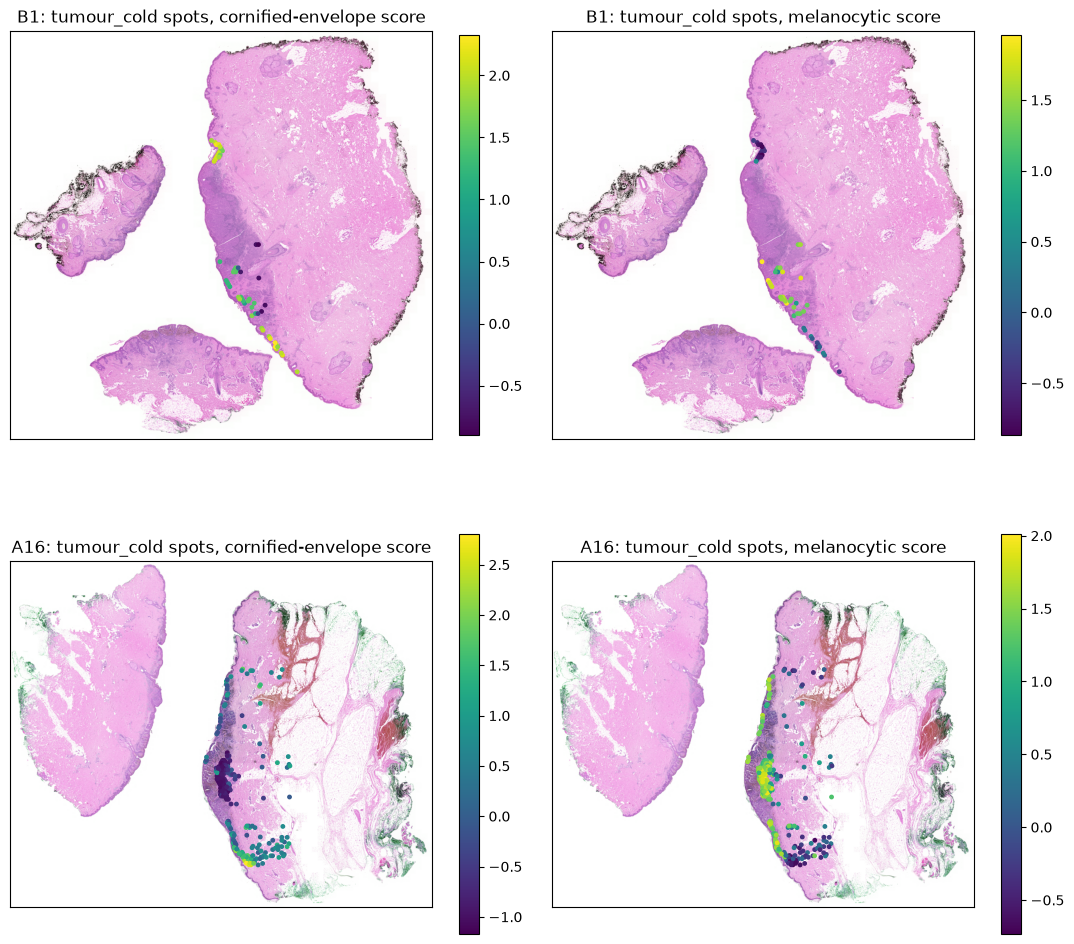

In [7]:
top_libs = per_lib_df.head(2)["library"].tolist() if len(per_lib_df) >= 2 else per_lib_df["library"].tolist()
fig, axes = plt.subplots(len(top_libs), 2, figsize=(11, 5.5 * len(top_libs)))
axes = np.atleast_2d(axes)
for row, lib in enumerate(top_libs):
    gsm = gl.list_libraries(RAW).set_index("library").loc[lib, "gsm"]
    lib_adata = gl.load_slide(RAW, gsm, only_in_tissue=True, load_images=True)[lib]
    lib_adata.obs_names = [f"{lib}_{bc}" for bc in lib_adata.obs["barcode"]]
    common = lib_adata.obs_names.intersection(cold_obs[cold_obs["library"] == lib].index)
    lib_cold = lib_adata[common]
    lib_cold.obs["score_cornified"] = cold_obs.loc[common, "score_cornified"].values
    lib_cold.obs["score_melanocytic"] = cold_obs.loc[common, "score_melanocytic"].values

    img = lib_adata.uns["spatial"][lib]["images"]["hires"]
    sf = lib_adata.uns["spatial"][lib]["scalefactors"]["tissue_hires_scalef"]
    for col, score_col, title in [(0, "score_cornified", "cornified-envelope score"),
                                   (1, "score_melanocytic", "melanocytic score")]:
        ax = axes[row, col]
        ax.imshow(img)
        xy = lib_cold.obsm["spatial"] * sf
        sca = ax.scatter(xy[:, 0], xy[:, 1], c=lib_cold.obs[score_col], s=6, cmap="viridis")
        ax.invert_yaxis()
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{lib}: tumour_cold spots, {title}")
        plt.colorbar(sca, ax=ax, shrink=0.7)
plt.tight_layout()
plt.savefig(FIGURES_OUT / "09_cornified_score_spatial.png", dpi=150)
plt.show()


## 5. Summary

In [8]:
combined.write_h5ad(PROCESSED_OUT / "09_epidermal_signal.h5ad")
print("Observed, from this notebook's own computation:")
print(f"- Within tumour_cold, melanocytic vs cornified score correlation: r={r_admixture:.2f} (section 2)")
print(f"- Cornified score vs hop-distance to nearest tumour_infiltrated spot (pooled): "
      f"r={r_cornified:.3f}, p={p_cornified:.2e}")
print(f"- Melanocytic score vs same distance: r={r_mel:.3f}, p={p_mel:.2e}")
print(f"- {(per_lib_df['cornified_vs_distance_r'] > 0).sum()}/{len(per_lib_df)} libraries individually show "
      "the predicted positive direction")
print("wrote data/processed/09_epidermal_signal.h5ad")


Observed, from this notebook's own computation:
- Within tumour_cold, melanocytic vs cornified score correlation: r=-0.45 (section 2)
- Cornified score vs hop-distance to nearest tumour_infiltrated spot (pooled): r=0.189, p=1.03e-45
- Melanocytic score vs same distance: r=-0.210, p=3.82e-56
- 11/15 libraries individually show the predicted positive direction
wrote data/processed/09_epidermal_signal.h5ad


## The result: the hypothesis held up, and section 4's images make the
case directly rather than just statistically.

**Section 2** showed `tumour_cold` is not one uniform population: melanocytic
and cornified scores are moderately anti-correlated (r=-0.45) at the spot
level, and sub-clustering split it into a clearly keratinocyte-dominant
group (2 of 6 sub-clusters, ~25% of spots, cornified score 1.8-2.2,
melanocytic score near zero) and a clearly melanocytic-dominant group (the
other 4, melanocytic score 0.9-1.4) with its own internal spread in
cornified signal - genuine heterogeneity, not a single smooth continuum.

**Section 3** found the predicted direction pooled across the dataset
(cornified score rises, melanocytic score falls, with distance from the
infiltrated margin - both p<1e-44) and, checked per library rather than
trusted pooled, in **11 of 15** testable libraries, including several of
the largest and most reliable ones (B1 r=0.60, A16 r=0.57, A17 r=0.49, A34
r=0.41) - real, reasonably widespread support, though not universal (A21
notably runs the other way).

**Section 4 is the most convincing piece.** In both libraries shown,
`tumour_cold` spots don't scatter through the tissue interior - they trace a
thin line hugging the tissue's *outer edge*, exactly where epidermis sits
anatomically. Within that same edge-hugging strip, the cornified-envelope
score is high at one end and the melanocytic score is high at the other -
a visible gradient along the tissue boundary, not just a number in a table.

**Put together:** `tumour_cold` (Cluster 6) is best described not as "the
melanocytic cluster" but as *the epidermis-proximal population*, spanning a
real gradient from more keratinocyte-admixed (closer to normal epidermis)
to more purely melanocytic (closer to where immune infiltration begins).
That maps directly onto the histological definition of the nevus-to-melanoma
transition this whole project is about: a junctional/in-situ component
against the epidermis, transitioning toward a more invasive, immune-engaged
front deeper in the tissue. This is not a claim about cell identity beyond
what marker-gene co-expression and spatial position support, and it is not
pathologist-verified - but it is now a real, specific, testable hypothesis
that the direct histology images support directly, not just a co-expression
result left dangling.